# Multioutput Gaussian Process Example

This notebook demonstrates the use of linear coregionalization for multiple output regression, where latent GPs are mixed to produce correlated multioutput responses. We illustrate the approach with simulations of increasing complexity: from a single example to multi-unit scenarios with kernel selection.

In [1]:
# Import required libraries
import gpflow
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.stats import nbinom

from waveome import regularization, utilities, kernels, likelihoods
from waveome.utilities import tqdm_joblib

# Configuration
f64 = gpflow.utilities.to_default_float
RANDOM_SEED = 9102
NBINOM_DISPERSION = 100.0  # Dispersion parameter for negative binomial

## Simple Single-Output Example

This example demonstrates the core concept: we generate data from two latent GPs with different kernels (smooth and rough), mix them via a matrix, and pass through a negative binomial likelihood. We then recover the latent structure using a linear coregionalization model with SVGP.

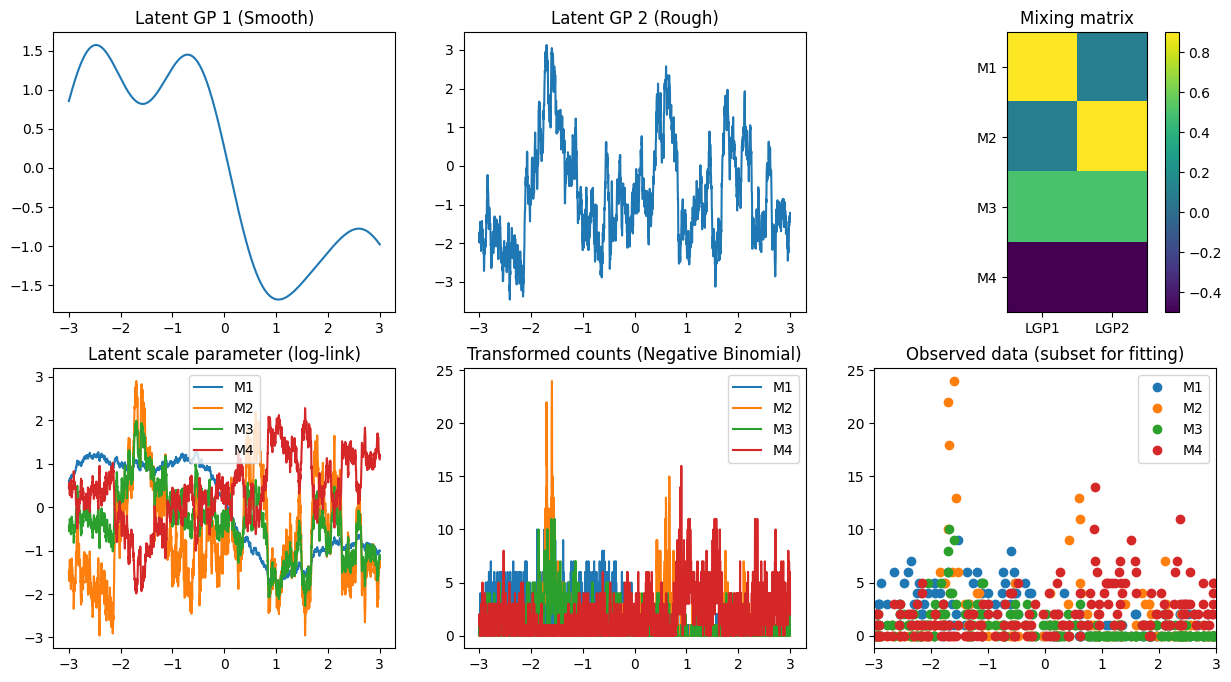

In [2]:
# Set up kernels for latent GPs
k1 = gpflow.kernels.SquaredExponential(variance=5., lengthscales=1.0)
k2 = gpflow.kernels.Matern12(variance=5., lengthscales=0.5)

# Mixing matrix: defines how latent GPs contribute to outputs
w_matrix = np.array([[0.9, 0.1],[0.1, 0.9],[.5, .5], [-.5, -.5]])

# Input points for full grid
x_grid = np.linspace(start=-3, stop=3, num=2000).reshape(-1, 1)
n_obs = 200

# Sample from latent GPs
np.random.seed(RANDOM_SEED)
lrv1 = np.random.multivariate_normal(
    mean=np.zeros_like(x_grid.flatten()),
    cov=k1.K(x_grid),
    size=1
).T

lrv2 = np.random.multivariate_normal(
    mean=np.zeros_like(x_grid.flatten()),
    cov=k2.K(x_grid),
    size=1
).T

# Mix latent GPs to create outputs
y_out = (w_matrix @ np.concatenate((lrv1, lrv2), axis=1).T).T

# Visualization
figs, axs = plt.subplots(2, 3, figsize=(15, 8))
axs[0, 0].plot(x_grid, lrv1)
axs[0, 0].set_title("Latent GP 1 (Smooth)")
axs[0, 1].plot(x_grid, lrv2)
axs[0, 1].set_title("Latent GP 2 (Rough)")
axs[0, 2].imshow(w_matrix)
axs[0, 2].set_title("Mixing matrix")
axs[0, 2].set_yticks([0, 1, 2, 3])
axs[0, 2].set_yticklabels(["M1", "M2", "M3", "M4"])
axs[0, 2].set_xticks([0, 1])
axs[0, 2].set_xticklabels(["LGP1", "LGP2"])
plt.colorbar(axs[0, 2].imshow(w_matrix), ax=axs[0, 2])

# Plot mixed scale parameters and observations
axs[1, 0].plot(x_grid, y_out, label=["M1", "M2", "M3", "M4"])
axs[1, 0].set_title("Latent scale parameter (log-link)")
axs[1, 0].legend()

# Sample from negative binomial likelihood
# Transform mean and dispersion to negative binomial parameters
mean_val = np.exp(y_out)
r = NBINOM_DISPERSION  # shape/dispersion parameter
p = r / (r + mean_val)  # convert to nbinom p parameter
obs_out = nbinom.rvs(n=r, p=p)
if obs_out.ndim == 0:
    obs_out = obs_out.reshape(1, -1)
if obs_out.shape != y_out.shape:
    obs_out = np.tile(obs_out, y_out.shape) if obs_out.shape[0] == 1 else obs_out

axs[1, 1].plot(x_grid, obs_out, label=["M1", "M2", "M3", "M4"])
axs[1, 1].set_title("Transformed counts (Negative Binomial)")
axs[1, 1].legend()

# Subset observations for model fitting
sub_idx = np.random.choice(a=range(len(x_grid)), size=n_obs, replace=False)
axs[1, 2].plot(x_grid[sub_idx], obs_out[sub_idx,:], 'o', label=["M1", "M2", "M3", "M4"])
axs[1, 2].set_xlim((-3, 3))
axs[1, 2].legend()
axs[1, 2].set_title("Observed data (subset for fitting)")
plt.show()

In [3]:
def optimize_multioutput_model(m, X, Y, hs_scale=0.1, orthog_weight=0.1, orthog_anneal_steps=1000, orthog_offdiag_only=True):

    # Set prior on W matrix to encourage sparsity
    m.kernel.W.prior = tfp.distributions.Horseshoe(f64(hs_scale))

    # Freeze variance components
    utilities.freeze_variance_parameters(m.kernel)

    # Use legacy Adam optimizer
    adam_opt = tf.keras.optimizers.Adam(learning_rate=0.01)
    natgrad_opt = gpflow.optimizers.NaturalGradient(gamma=0.1)

    # Don't let Adam update q_mu, q_sqrt
    natgrad_vars = [(m.q_mu, m.q_sqrt)]
    gpflow.set_trainable(m.q_mu, False)
    gpflow.set_trainable(m.q_sqrt, False)

    num_iterations = 5000
    loss_history = []
    best_loss = float('inf')
    patience = 500
    iterations_no_improve = 0
    constraint_weight = f64(1.0)

    # Orthogonality annealing variable (tf.Variable so it can be captured by @tf.function)
    orthog_w_tf = tf.Variable(f64(0.0), trainable=False)

    def loss_fn():
        return m.training_loss((X, Y))

    @tf.function
    def optimization_step():

        # Optimize variational parameters
        natgrad_opt.minimize(loss_fn, var_list=natgrad_vars)

        # Optimize kernel and likelihood parameters
        with tf.GradientTape() as tape:
            loss = loss_fn()
            
            # Add identifiability constraints to loss with WEAK weighting
            W = m.kernel.W
            
            # 1. Weak sign constraint: encourage first element to be positive
            sign_penalty = tf.reduce_sum(tf.nn.relu(-W[0, :]))
            
            # 2. Optional orthogonality constraint on W columns (soft penalty)
            try:
                WTW = tf.matmul(tf.transpose(W), W)
                if orthog_offdiag_only:
                    # Penalize off-diagonal elements only (encourages decorrelation)
                    offdiag = WTW - tf.linalg.tensor_diag(tf.linalg.diag_part(WTW))
                    orthog_penalty = tf.reduce_sum(tf.square(offdiag))
                else:
                    num_latent = tf.cast(tf.shape(W)[1], tf.int32)
                    identity = tf.eye(num_latent, dtype=tf.float64)
                    orthog_penalty = tf.reduce_sum(tf.square(WTW - identity))
            except Exception:
                orthog_penalty = f64(0.0)

            # Total loss with weak constraint weighting and optional orthogonality penalty
            total_loss = loss + constraint_weight * sign_penalty + orthog_w_tf * orthog_penalty
            
        grads = tape.gradient(total_loss, m.trainable_variables)
        
        # Clip gradients to prevent explosion
        clipped_grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
        
        adam_opt.apply_gradients(zip(clipped_grads, m.trainable_variables))
        return total_loss, loss

    for i in range(num_iterations):
        # Anneal orthogonality weight if requested
        if orthog_anneal_steps and orthog_anneal_steps > 0:
            cur_w = min(1.0, float(i) / float(orthog_anneal_steps)) * float(orthog_weight)
        else:
            cur_w = float(orthog_weight)
        orthog_w_tf.assign(f64(cur_w))

        # Calculate loss
        total_loss, data_loss = optimization_step()
        loss_val = data_loss.numpy()
        total_loss_val = total_loss.numpy()
        
        loss_history.append(loss_val)
        
        # Check for NaN/Inf and stop if detected
        if np.isnan(loss_val) or np.isinf(loss_val):
            print(f"Iteration {i}: WARNING - Loss became NaN/Inf: Loss = {loss_val:.6f}")
            print("Stopping optimization to prevent divergence.")
            break
        
        # Early stopping based on loss improvement
        if loss_val < best_loss:
            best_loss = loss_val
            iterations_no_improve = 0
        else:
            iterations_no_improve += 1
            if iterations_no_improve >= patience:
                print(f"Iteration {i}: Early stopping - no improvement for {patience} iterations")
                break
        
        if i % 500 == 0:
            print(f"Iteration {i}: Loss = {loss_val:.6f}, Total Loss = {total_loss_val:.6f}")

    print(f"\nFinal loss: {loss_val:.6f}")
    print(f"Final total loss (with constraints): {total_loss_val:.6f}")
    return m


In [4]:
num_latent_gps = 2

# Use sampled data for training (not the full grid)
X_train = x_grid[sub_idx].astype(float)
Y_train = obs_out[sub_idx, :].astype(float)
np.random.seed(RANDOM_SEED)

# Specify model
m = gpflow.models.SVGP(
    kernel=gpflow.kernels.LinearCoregionalization(
        kernels=[
            gpflow.kernels.SquaredExponential(),
            gpflow.kernels.Matern12()
        ],
        W=np.random.normal(size=(np.shape(Y_train)[1], num_latent_gps))
    ),
    likelihood=likelihoods.NegativeBinomial(),
    inducing_variable=gpflow.inducing_variables.SeparateIndependentInducingVariables(
        [gpflow.inducing_variables.InducingPoints(X_) for X_ in [X_train.copy() for _ in range(num_latent_gps)]]
    ),
    num_latent_gps=num_latent_gps
)

# Optimize hyperparameters
# Final loss = 1139.503856
# Final loss (with orthogonality penalty) = 1140.077840
m = optimize_multioutput_model(m, X_train, Y_train, orthog_weight=0.1, orthog_anneal_steps=1000)


Instructions for updating:
Use fn_output_signature instead


Instructions for updating:
Use fn_output_signature instead


Iteration 0: Loss = 1405.293391, Total Loss = 1406.230855
Iteration 500: Loss = 1216.024569, Total Loss = 1216.746850
Iteration 1000: Loss = 1149.376716, Total Loss = 1149.384379
Iteration 1500: Loss = 1141.853511, Total Loss = 1141.867151
Iteration 2000: Loss = 1140.058637, Total Loss = 1140.107042
Iteration 2493: Early stopping - no improvement for 500 iterations

Final loss: 1140.038496
Final total loss (with constraints): 1140.077840


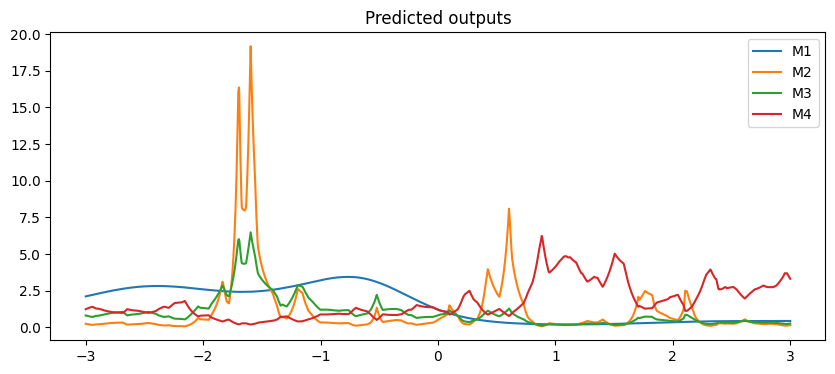

In [5]:
# Predict on full grid
mu_, var_ = m.predict_y(x_grid)
plt.figure(figsize=(10, 4))
plt.plot(x_grid, mu_, label=["M1", "M2", "M3", "M4"])
plt.legend()
plt.title("Predicted outputs")
plt.show()

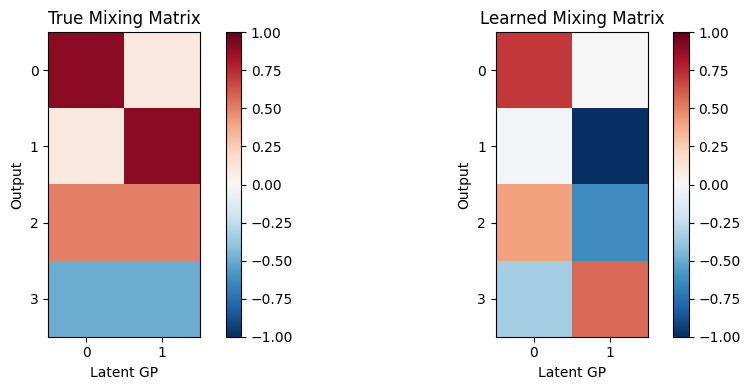

True mixing matrix:
[[ 0.9  0.1]
 [ 0.1  0.9]
 [ 0.5  0.5]
 [-0.5 -0.5]]

Learned mixing matrix:
[[ 0.71  0.  ]
 [-0.01 -1.38]
 [ 0.41 -0.63]
 [-0.35  0.56]]

MSE between matrices: 0.961126


In [6]:
# Compare learned mixing matrix with true mixing matrix
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# True mixing matrix
im1 = axs[0].imshow(w_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axs[0].set_title("True Mixing Matrix")
axs[0].set_ylabel("Output")
axs[0].set_xlabel("Latent GP")
axs[0].set_xticks([0, 1])
axs[0].set_yticks([0, 1, 2, 3])
plt.colorbar(im1, ax=axs[0])

# Learned mixing matrix
im2 = axs[1].imshow(m.kernel.W.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
axs[1].set_title("Learned Mixing Matrix")
axs[1].set_ylabel("Output")
axs[1].set_xlabel("Latent GP")
axs[1].set_xticks([0, 1])
axs[1].set_yticks([0, 1, 2, 3])
plt.colorbar(im2, ax=axs[1])

plt.tight_layout()
plt.show()

# Print numerical comparison
print("True mixing matrix:")
print(w_matrix)
print("\nLearned mixing matrix:")
print(m.kernel.W.numpy().round(2))
print(f"\nMSE between matrices: {np.mean((w_matrix - m.kernel.W.numpy())**2):.6f}")

In [7]:
# Check if learned latent functions recover the true structure
mu_learned, _ = m.predict_f(x_grid)

# Try to recover original latents using pseudo-inverse
# W has shape (4, 2), so we need W.T^+ to map from outputs (4,) to latents (2,)
latents_recovered = mu_learned.numpy() @ np.linalg.pinv(m.kernel.W.numpy().T)

# Compare against true latents
mse_lv1_true = np.mean((lrv1 - latents_recovered[:, 0])**2)
mse_lv2_true = np.mean((lrv2 - latents_recovered[:, 1])**2)

print(f"MSE recovering Latent 1: {mse_lv1_true:.6f}")
print(f"MSE recovering Latent 2: {mse_lv2_true:.6f}")

# Also check if the output predictions are good
mu_out_true = w_matrix @ np.array([lrv1.flatten(), lrv2.flatten()])
mu_out_learned = latents_recovered @ m.kernel.W.numpy().T
mse_output = np.mean((mu_out_true.T - mu_out_learned)**2)
print(f"MSE of output predictions: {mse_output:.6f}")

MSE recovering Latent 1: 3.708703
MSE recovering Latent 2: 3.951975
MSE of output predictions: 0.130248


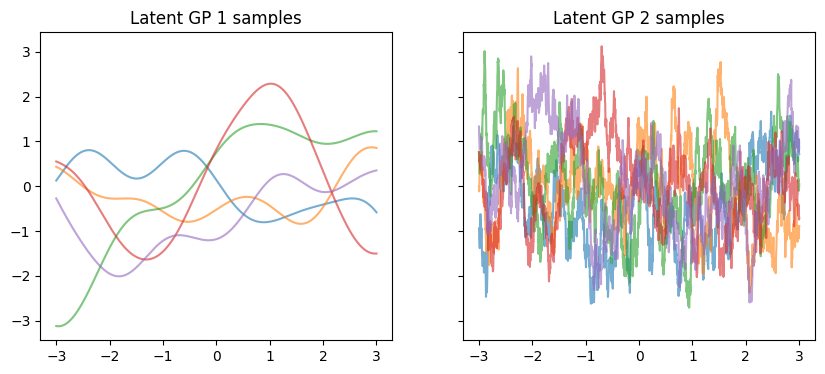

In [8]:
# Sample posterior samples from latent GPs
np.random.seed(RANDOM_SEED)
lrv1_post = np.random.multivariate_normal(
    mean=np.zeros_like(x_grid.flatten()),
    cov=m.kernel.latent_kernels[0].K(x_grid),
    size=5
).T

lrv2_post = np.random.multivariate_normal(
    mean=np.zeros_like(x_grid.flatten()),
    cov=m.kernel.latent_kernels[1].K(x_grid),
    size=5
).T

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(x_grid, lrv1_post, alpha=0.6)
axs[0].set_title("Latent GP 1 samples")
axs[1].plot(x_grid, lrv2_post, alpha=0.6)
axs[1].set_title("Latent GP 2 samples")
plt.show()

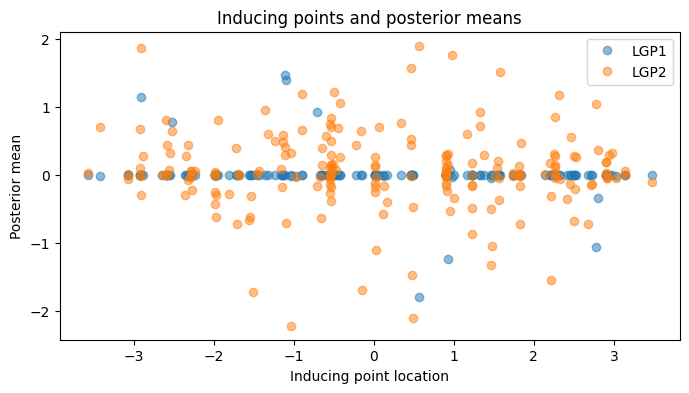

In [9]:
# Inspect inducing point locations
plt.figure(figsize=(8, 4))
plt.plot(
    m.inducing_variable.inducing_variable_list[0].Z.numpy(), 
    m.q_mu.numpy()[:len(m.inducing_variable.inducing_variable_list[0].Z.numpy())],
    'o',
    alpha=0.5,
    label=["LGP1", "LGP2"]
)
plt.xlabel("Inducing point location")
plt.ylabel("Posterior mean")
plt.title("Inducing points and posterior means")
plt.legend()
plt.show()

In [10]:
# Extract and visualize latent function posteriors
mu_hat, var_hat = m.predict_f(x_grid)

# Recover latent means using pseudo-inverse of mixing matrix
l_mu_hat = mu_hat @ tf.transpose(tf.linalg.pinv(m.kernel.W))

# Center means
l_mu_hat = l_mu_hat - tf.math.reduce_mean(l_mu_hat, axis=0)

# Recover latent variances
# Using variance propagation: V(aX+bY) = a²V(X) + b²V(Y) + 2abCov(X,Y)
l_var_hat = tf.transpose(tf.linalg.pinv((m.kernel.W)**2) @ tf.transpose(var_hat))

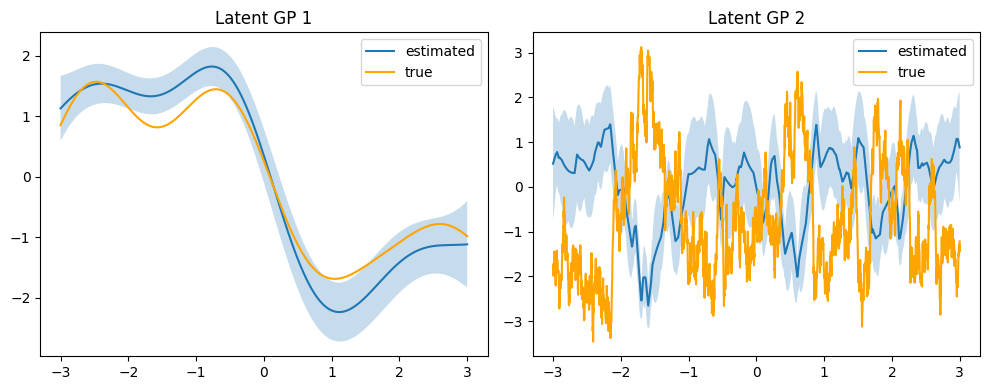

In [11]:
# Plot recovered latent functions
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for i in range(2):
    axs[i].fill_between(
        x=x_grid.flatten(), 
        y1=l_mu_hat[:, i] - 1.96*np.sqrt(l_var_hat[:, i]),
        y2=l_mu_hat[:, i] + 1.96*np.sqrt(l_var_hat[:, i]),
        alpha=0.25
    )
    axs[i].plot(x_grid, l_mu_hat[:, i], label="estimated")
    
    # Add true latent function
    if i == 0:
        true_obs_ = lrv1
    elif i == 1:
        true_obs_ = lrv2
    axs[i].plot(x_grid, true_obs_, c="orange", label="true")
    
    axs[i].set_title(f"Latent GP {i+1}")
    axs[i].legend()

plt.tight_layout()
plt.show()

## Multi-Unit Example

Now we extend to a scenario with multiple independent units, where each unit has its own observations. We use a mixture of unit-specific (categorical) and global (time-varying) kernels to capture both individual variation and common patterns.

In [12]:
k1_ind = gpflow.kernels.SquaredExponential(active_dims=[1])
k2_ind = kernels.Categorical(active_dims=[0]) * gpflow.kernels.Matern12(variance=1., lengthscales=0.5, active_dims=[1])

x_grid = np.linspace(start=-3, stop=3, num=100).reshape(-1, 1)
# True mixing matrix expanded to 4 outputs × 5 latent GPs (with 3 zeros for unused latents)
multi_w_matrix = np.array([[0.9, 0., 0., 0., 0.1],
                            [0.1, 0., 0., 0., 0.9],
                            [0.5, 0., 0., 0., 0.5],
                            [-0.5, 0., 0., 0., -0.5]])
ids = np.arange(start=1, stop=51) # originally 10 ids
id_grid = np.repeat(ids, len(x_grid)).reshape(-1, 1).astype(float)
multi_x_grid = np.tile(x_grid.flatten(), len(ids)).reshape(-1, 1)
multi_x_grid = np.hstack((id_grid, multi_x_grid))

In [13]:
n = id_grid.flatten().size
print("n points:", n)
import time, numpy as np
K = k1_ind(multi_x_grid)
print("K shape:", K.shape)
t0 = time.time()
_ = np.linalg.cholesky(K + 1e-6*np.eye(n))   # times the factorization step
print("chol time:", time.time()-t0)

n points: 5000
K shape: (5000, 5000)
chol time: 0.7050299644470215


In [14]:
# Generate data for multi-unit scenario
np.random.seed(RANDOM_SEED)

# Shared (smooth) component across units
lrv1_multi = np.random.multivariate_normal(
    mean=np.zeros_like(id_grid.flatten()),
    cov=k1_ind(multi_x_grid),
    size=1
).T

# Unit-specific (rough) component
lrv2_multi = np.random.multivariate_normal(
    mean=np.zeros_like(id_grid.flatten()),
    cov=k2_ind(multi_x_grid),
    size=1
).T

# Mix latent GPs: concatenate 2 true latents with 3 zero latents (to match multi_w_matrix structure)
latents_all = np.concatenate((lrv1_multi, np.zeros_like(lrv1_multi), np.zeros_like(lrv1_multi), np.zeros_like(lrv1_multi), lrv2_multi), axis=1)
multi_mu = (multi_w_matrix @ latents_all.T).T

# Sample from negative binomial likelihood
mean_val = np.exp(multi_mu)
r = NBINOM_DISPERSION
p = r / (r + mean_val)
multi_y = nbinom.rvs(n=r, p=p)
if multi_y.ndim == 1:
    multi_y = multi_y.reshape(-1, 1)
if multi_y.shape != multi_mu.shape:
    multi_y = np.full_like(multi_mu, multi_y.ravel()[0] if multi_y.size == 1 else 0)
# Convert to float64 for TensorFlow compatibility
multi_y = multi_y.astype(np.float64)

In [15]:
# Subsample data: obs_per_unit observations per unit for training
np.random.seed(RANDOM_SEED)
obs_per_unit = 10 # originally 50 observations per unit
multi_x_grid_train = []
multi_y_train = []

for unit_id in np.unique(id_grid):
    unit_mask = multi_x_grid[:, 0] == unit_id
    unit_indices = np.where(unit_mask)[0]
    
    # Randomly sample 50 observations from this unit
    sampled_indices = np.random.choice(unit_indices, size=min(obs_per_unit, len(unit_indices)), replace=False)
    
    multi_x_grid_train.append(multi_x_grid[sampled_indices])
    multi_y_train.append(multi_y[sampled_indices])

# Concatenate all units
multi_x_grid_train = np.vstack(multi_x_grid_train)
multi_y_train = np.vstack(multi_y_train)

# Convert to float64 for TensorFlow compatibility
multi_y_train = multi_y_train.astype(np.float64)

print(f"Full dataset shape: {multi_x_grid.shape} x {multi_y.shape}")
print(f"Training dataset shape: {multi_x_grid_train.shape} x {multi_y_train.shape}")
print(f"Observations per unit: {obs_per_unit}")

Full dataset shape: (5000, 2) x (5000, 4)
Training dataset shape: (500, 2) x (500, 4)
Observations per unit: 10


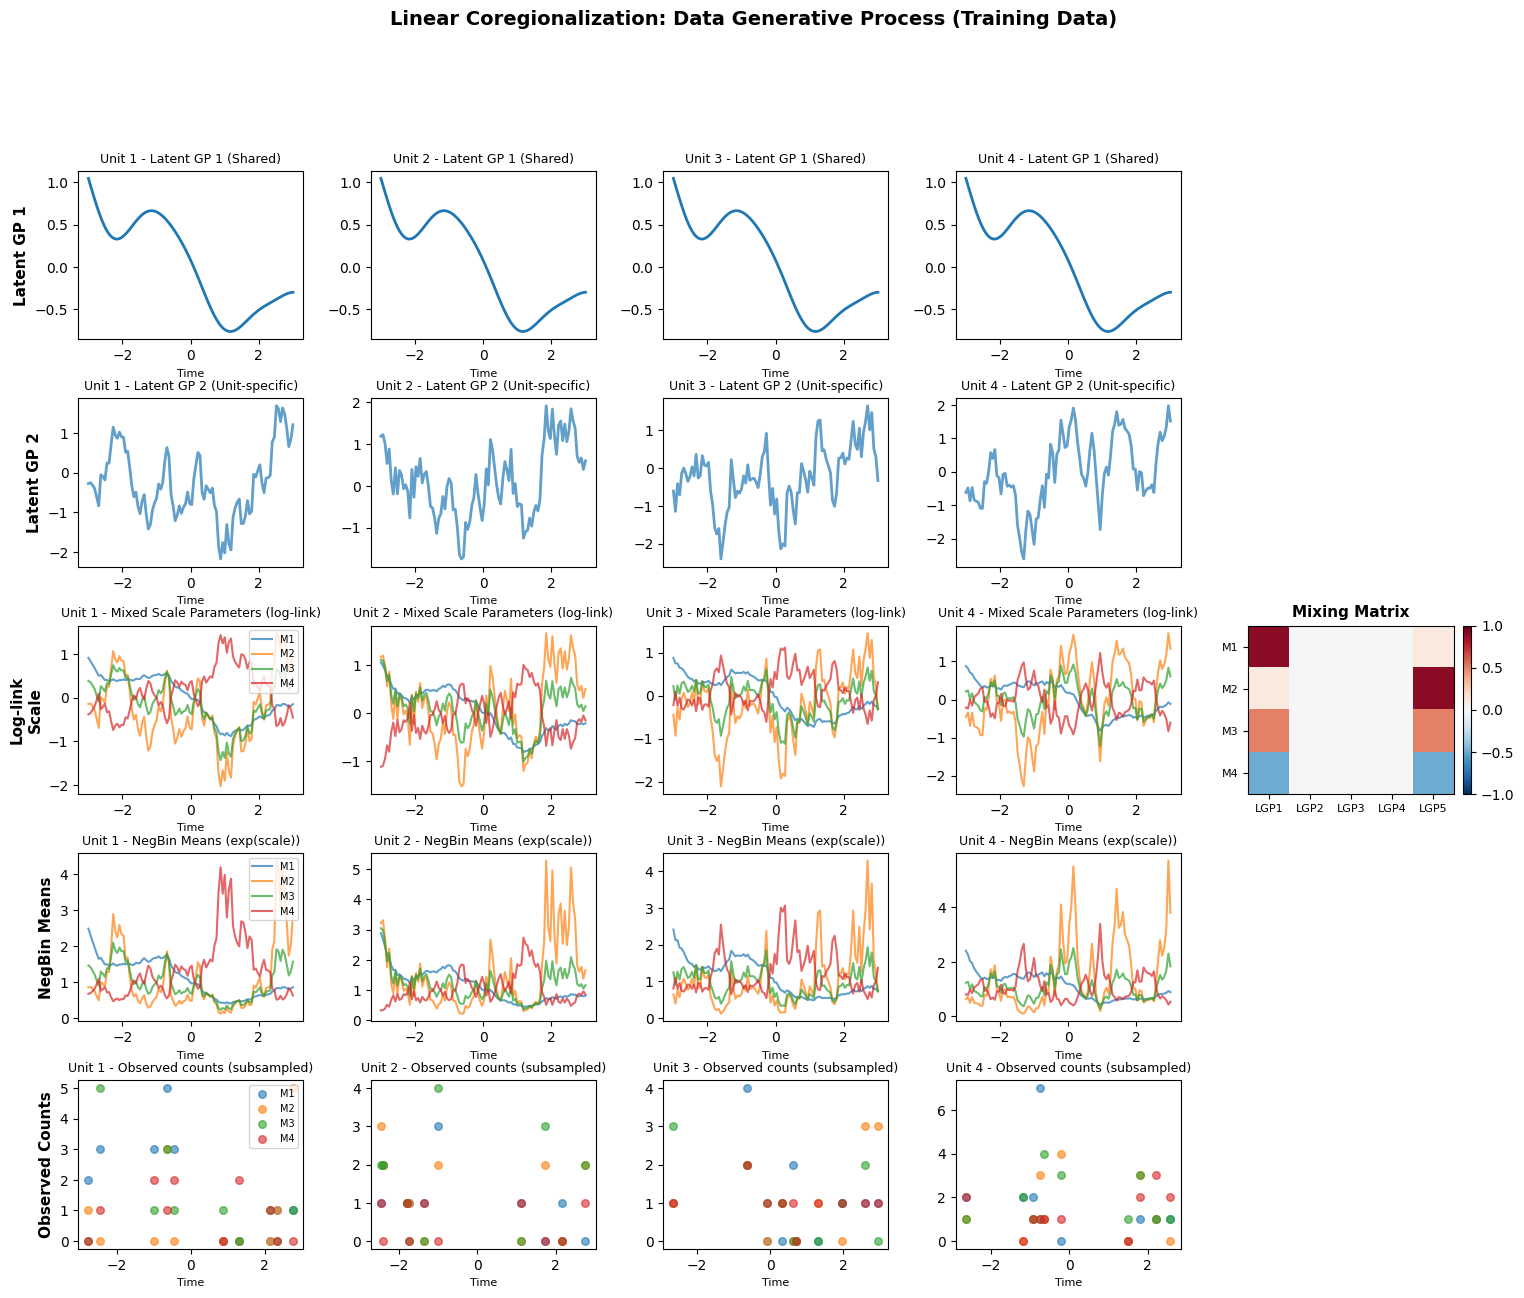

In [16]:
# Visualize multi-unit data structure with five stages
# Bottom row shows only the subsampled observations
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(5, 5, hspace=0.35, wspace=0.3)

# Create axes for main grid (5 rows x 4 columns for units)
axs_main = []
for i in range(5):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axs_main.append(row_axes)

# Add mixing matrix in row 2 (index 2), column 4 (index 4)
ax_mixing = fig.add_subplot(gs[2, 4])
im = ax_mixing.imshow(multi_w_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_mixing.set_title("Mixing Matrix", fontsize=11, fontweight='bold')
ax_mixing.set_yticks([0, 1, 2, 3])
ax_mixing.set_yticklabels(["M1", "M2", "M3", "M4"], fontsize=8)
ax_mixing.set_xticks(range(5))
ax_mixing.set_xticklabels([f"LGP{i+1}" for i in range(5)], fontsize=8)
plt.colorbar(im, ax=ax_mixing, fraction=0.046, pad=0.04)

# axs[0].set_ylabel("Output", fontsize=10)
# axs[0].set_xlabel("Latent GP", fontsize=10)

# Plot latent GP 1 (Smooth - Shared) - only first 4 units
for unit_id in np.unique(id_grid)[:4]:
    unit_mask = multi_x_grid[:, 0] == unit_id
    axs_main[0][int(unit_id)-1].plot(multi_x_grid[unit_mask, 1], lrv1_multi[unit_mask, 0], linewidth=2)
    axs_main[0][int(unit_id)-1].set_title(f"Unit {int(unit_id)} - Latent GP 1 (Shared)", fontsize=9)
    axs_main[0][int(unit_id)-1].set_xlabel("Time", fontsize=8)

# Plot latent GP 2 (Rough - Unit-specific) - only first 4 units
for unit_id in np.unique(id_grid)[:4]:
    unit_mask = multi_x_grid[:, 0] == unit_id
    axs_main[1][int(unit_id)-1].plot(multi_x_grid[unit_mask, 1], lrv2_multi[unit_mask, 0], linewidth=2, alpha=0.7)
    axs_main[1][int(unit_id)-1].set_title(f"Unit {int(unit_id)} - Latent GP 2 (Unit-specific)", fontsize=9)
    axs_main[1][int(unit_id)-1].set_xlabel("Time", fontsize=8)

# Plot mixed scale parameters (log scale) - only first 4 units
for unit_id in np.unique(id_grid)[:4]:
    unit_mask = multi_x_grid[:, 0] == unit_id
    for output_idx in range(multi_mu.shape[1]):
        axs_main[2][int(unit_id)-1].plot(multi_x_grid[unit_mask, 1], multi_mu[unit_mask, output_idx], 
                                    alpha=0.7, label=f"M{output_idx+1}", linewidth=1.5)
    axs_main[2][int(unit_id)-1].set_title(f"Unit {int(unit_id)} - Mixed Scale Parameters (log-link)", fontsize=9)
    axs_main[2][int(unit_id)-1].set_xlabel("Time", fontsize=8)
    if int(unit_id) == 1:
        axs_main[2][int(unit_id)-1].legend(fontsize=7, loc='upper right')

# Plot NegBin transformed means (exp of scale parameters) - only first 4 units
for unit_id in np.unique(id_grid)[:4]:
    unit_mask = multi_x_grid[:, 0] == unit_id
    for output_idx in range(multi_mu.shape[1]):
        axs_main[3][int(unit_id)-1].plot(multi_x_grid[unit_mask, 1], np.exp(multi_mu[unit_mask, output_idx]), 
                                    alpha=0.7, label=f"M{output_idx+1}", linewidth=1.5)
    axs_main[3][int(unit_id)-1].set_title(f"Unit {int(unit_id)} - NegBin Means (exp(scale))", fontsize=9)
    axs_main[3][int(unit_id)-1].set_xlabel("Time", fontsize=8)
    if int(unit_id) == 1:
        axs_main[3][int(unit_id)-1].legend(fontsize=7, loc='upper right')

# Plot observed counts - only the SUBSAMPLED observations - only first 4 units
for unit_id in np.unique(id_grid)[:4]:
    unit_mask = multi_x_grid_train[:, 0] == unit_id
    for output_idx in range(multi_y_train.shape[1]):
        axs_main[4][int(unit_id)-1].scatter(multi_x_grid_train[unit_mask, 1], multi_y_train[unit_mask, output_idx], 
                                       alpha=0.6, s=30, label=f"M{output_idx+1}")
    axs_main[4][int(unit_id)-1].set_title(f"Unit {int(unit_id)} - Observed counts (subsampled)", fontsize=9)
    axs_main[4][int(unit_id)-1].set_xlabel("Time", fontsize=8)
    if int(unit_id) == 1:
        axs_main[4][int(unit_id)-1].legend(fontsize=7, loc='upper right')

# Add row labels
axs_main[0][0].set_ylabel("Latent GP 1", fontsize=11, fontweight='bold')
axs_main[1][0].set_ylabel("Latent GP 2", fontsize=11, fontweight='bold')
axs_main[2][0].set_ylabel("Log-link\nScale", fontsize=11, fontweight='bold')
axs_main[3][0].set_ylabel("NegBin Means", fontsize=11, fontweight='bold')
axs_main[4][0].set_ylabel("Observed Counts", fontsize=11, fontweight='bold')

plt.suptitle("Linear Coregionalization: Data Generative Process (Training Data)", fontsize=14, fontweight='bold', y=0.995)
plt.show()

In [28]:
# Fit multioutput model with SVGP on subsampled training data
num_latent_gps = 5

# Use the subsampled training data (50 observations per unit)
# multi_y_train is already float64 from the previous cell
np.random.seed(9102)

# Fit SVGP with linear coregionalization
m_multi = gpflow.models.SVGP(
    kernel=gpflow.kernels.LinearCoregionalization(
        kernels=[
            gpflow.kernels.SquaredExponential(active_dims=[1]),
            gpflow.kernels.Matern12(active_dims=[1]),
            kernels.Categorical(active_dims=[0]),
            kernels.Categorical(active_dims=[0]) * gpflow.kernels.SquaredExponential(active_dims=[1]),
            kernels.Categorical(active_dims=[0]) * gpflow.kernels.Matern12(active_dims=[1])
        ],
        W=np.random.normal(size=(np.shape(multi_y_train)[1], num_latent_gps))
    ),
    likelihood=likelihoods.NegativeBinomial(),
    inducing_variable=gpflow.inducing_variables.SeparateIndependentInducingVariables(
        [gpflow.inducing_variables.InducingPoints(X_) for X_ in [multi_x_grid_train.copy() for _ in range(num_latent_gps)]]
    ),
    num_latent_gps=num_latent_gps
)

m_multi = optimize_multioutput_model(m_multi, multi_x_grid_train, multi_y_train, orthog_weight=0, hs_scale=0.1)
gpflow.utilities.print_summary(m_multi)

Iteration 0: Loss = 3966.843838, Total Loss = 3968.264267
Iteration 500: Loss = 2872.054135, Total Loss = 2872.468449
Iteration 1000: Loss = 2873.707094, Total Loss = 2874.109587
Iteration 1099: Early stopping - no improvement for 500 iterations

Final loss: 2872.578199
Final total loss (with constraints): 2872.972114
╒════════════════════════════════════════════════════╤═══════════╤════════════════╤═══════════╤═════════════╤═══════════════╤═════════╤════════════════════════════════════════════════════════╕
│ name                                               │ class     │ transform      │ prior     │ trainable   │ shape         │ dtype   │ value                                                  │
╞════════════════════════════════════════════════════╪═══════════╪════════════════╪═══════════╪═════════════╪═══════════════╪═════════╪════════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance                    │ Parameter │ Softplus       │           │ False

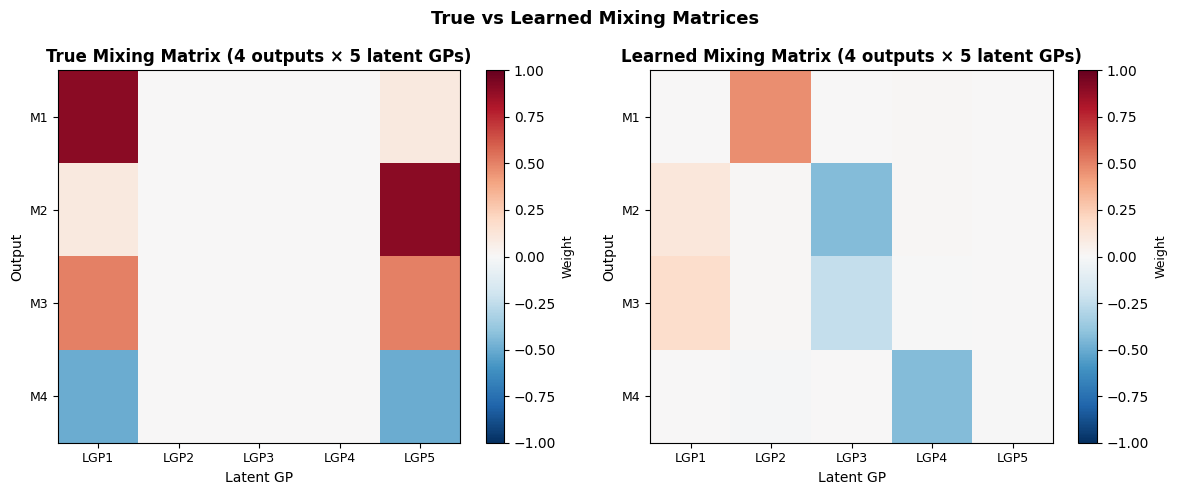

True Mixing Matrix (4 outputs × 5 latent GPs):
[[ 0.9  0.   0.   0.   0.1]
 [ 0.1  0.   0.   0.   0.9]
 [ 0.5  0.   0.   0.   0.5]
 [-0.5  0.   0.   0.  -0.5]]

Learned Mixing Matrix (4 outputs × 5 latent GPs):
[[ 6.100e-03  4.687e-01  4.200e-03  8.400e-03  3.700e-03]
 [ 1.101e-01  8.800e-03 -4.321e-01  8.600e-03  5.400e-03]
 [ 1.779e-01  1.540e-02 -2.369e-01 -3.600e-03  5.500e-03]
 [ 1.500e-03 -9.500e-03  4.900e-03 -4.341e-01 -4.000e-04]]

Comparison of true vs learned mixing matrices:
  MSE (overall): 0.155488
  MAE (overall): 0.267388

Model structure comparison:
  Magnitude of learned cols 3-5 (extra latents): 0.095646
  Sparsity in cols 3-5 (fraction < 0.1): 0.750


In [18]:
# Compare true and learned mixing matrices for multi-unit model
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# True mixing matrix (4 outputs × 5 latent GPs, with 3 zeros)
im1 = axs[0].imshow(multi_w_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axs[0].set_title("True Mixing Matrix (4 outputs × 5 latent GPs)", fontsize=12, fontweight='bold')
axs[0].set_ylabel("Output", fontsize=10)
axs[0].set_xlabel("Latent GP", fontsize=10)
axs[0].set_yticks([0, 1, 2, 3])
axs[0].set_yticklabels(["M1", "M2", "M3", "M4"], fontsize=9)
axs[0].set_xticks(range(5))
axs[0].set_xticklabels([f"LGP{i+1}" for i in range(5)], fontsize=9)
cbar1 = plt.colorbar(im1, ax=axs[0])
cbar1.set_label("Weight", fontsize=9)

# Learned mixing matrix
W_learned = m_multi.kernel.W.numpy()
im2 = axs[1].imshow(W_learned, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axs[1].set_title("Learned Mixing Matrix (4 outputs × 5 latent GPs)", fontsize=12, fontweight='bold')
axs[1].set_ylabel("Output", fontsize=10)
axs[1].set_xlabel("Latent GP", fontsize=10)
axs[1].set_yticks([0, 1, 2, 3])
axs[1].set_yticklabels(["M1", "M2", "M3", "M4"], fontsize=9)
axs[1].set_xticks(range(5))
axs[1].set_xticklabels([f"LGP{i+1}" for i in range(5)], fontsize=9)
cbar2 = plt.colorbar(im2, ax=axs[1])
cbar2.set_label("Weight", fontsize=9)

plt.suptitle("True vs Learned Mixing Matrices", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("True Mixing Matrix (4 outputs × 5 latent GPs):")
print(multi_w_matrix)
print("\nLearned Mixing Matrix (4 outputs × 5 latent GPs):")
print(W_learned.round(4))

# Compare: first 2 columns (true latent GPs) - shape match for MSE/MAE
print(f"\nComparison of true vs learned mixing matrices:")
mse_all = np.mean((multi_w_matrix - W_learned)**2)
mae_all = np.mean(np.abs(multi_w_matrix - W_learned))
print(f"  MSE (overall): {mse_all:.6f}")
print(f"  MAE (overall): {mae_all:.6f}")

# Overall fit metrics
print(f"\nModel structure comparison:")
print(f"  Magnitude of learned cols 3-5 (extra latents): {np.mean(np.abs(W_learned[:, 2:])):.6f}")
print(f"  Sparsity in cols 3-5 (fraction < 0.1): {np.sum(np.abs(W_learned[:, 2:]) < 0.1) / (4*3):.3f}")

In [19]:
# Evaluate model closeness to true data generating distribution
print("=" * 70)
print("MODEL EVALUATION: Closeness to True Data Generating Distribution")
print("=" * 70)

# 1. Mixing Matrix Information
print("\n1. MIXING MATRIX & MODEL STRUCTURE")
print("-" * 70)
W_learned = m_multi.kernel.W.numpy()
print("True mixing matrix W_true (4 outputs × 2 true latent GPs):")
print(multi_w_matrix)
print(f"\nLearned mixing matrix W_learned (4 outputs × {W_learned.shape[1]} learned latent GPs):")
print(W_learned.round(4))
print(f"Note: Model learned {W_learned.shape[1]} latent GPs vs {w_matrix.shape[1]} true latent GPs")

# 2. Scale Parameter Prediction
print("\n2. SCALE PARAMETER PREDICTION (Log-link)")
print("-" * 70)
# Use the predict_y to get output predictions
y_pred, y_var_pred = m_multi.predict_y(multi_x_grid)
y_pred = y_pred.numpy()

# Compute MSE vs true scale parameters
mse_mu = np.mean((multi_mu - y_pred) ** 2)
mae_mu = np.mean(np.abs(multi_mu - y_pred))
rmse_mu = np.sqrt(mse_mu)

print(f"Predicted scale parameters (μ = W @ [LGP1, LGP2, ...]):")
print(f"  MSE: {mse_mu:.6f}")
print(f"  MAE: {mae_mu:.6f}")
print(f"  RMSE: {rmse_mu:.6f}")

# 3. Transformed Mean Recovery
print("\n3. TRANSFORMED MEAN RECOVERY (Negative Binomial Means)")
print("-" * 70)
true_means = np.exp(multi_mu)
learned_means = np.exp(y_pred)
mse_means = np.mean((true_means - learned_means) ** 2)
mae_means = np.mean(np.abs(true_means - learned_means))
rmse_means = np.sqrt(mse_means)

print(f"Exp-transformed means E[Y | f] = exp(μ):")
print(f"  MSE: {mse_means:.6f}")
print(f"  MAE: {mae_means:.6f}")
print(f"  RMSE: {rmse_means:.6f}")

# 4. Observed Count Prediction
print("\n4. OBSERVED COUNT PREDICTION")
print("-" * 70)
# Per-output statistics
print(f"Prediction error by output:")
for output_idx in range(4):
    mse_out = np.mean((multi_y[:, output_idx] - y_pred[:, output_idx]) ** 2)
    mae_out = np.mean(np.abs(multi_y[:, output_idx] - y_pred[:, output_idx]))
    print(f"  M{output_idx+1}: MSE={mse_out:.6f}, MAE={mae_out:.6f}")

# Overall
mse_y_full = np.mean((multi_y - y_pred) ** 2)
mae_y_full = np.mean(np.abs(multi_y - y_pred))
print(f"\nOverall: MSE={mse_y_full:.6f}, MAE={mae_y_full:.6f}")

# 5. Predictive Distribution Comparison
print("\n5. PREDICTIVE DISTRIBUTION ON DATA")
print("-" * 70)

# Likelihood evaluation on training data
log_pred_prob_train = m_multi.predict_log_density((multi_x_grid_train, multi_y_train))
avg_log_lik_train = np.mean(log_pred_prob_train.numpy())
print(f"Average log-likelihood on TRAINING data: {avg_log_lik_train:.6f}")

# Likelihood evaluation on full data
log_pred_prob_full = m_multi.predict_log_density((multi_x_grid, multi_y))
avg_log_lik_full = np.mean(log_pred_prob_full.numpy())
print(f"Average log-likelihood on FULL data: {avg_log_lik_full:.6f}")

# 6. Summary of Model Quality
print("\n6. MODEL QUALITY SUMMARY")
print("-" * 70)
print(f"✓ Scale parameter recovery (↓ better): {mse_mu:.6f}")
print(f"✓ Transformed means recovery (↓ better): {mse_means:.6f}")
print(f"✓ Count prediction error (↓ better): {mse_y_full:.6f}")
print(f"✓ Log-likelihood on training (↑ better): {avg_log_lik_train:.6f}")
print(f"✓ Log-likelihood on full data (↑ better): {avg_log_lik_full:.6f}")
print("\n" + "=" * 70)

MODEL EVALUATION: Closeness to True Data Generating Distribution

1. MIXING MATRIX & MODEL STRUCTURE
----------------------------------------------------------------------
True mixing matrix W_true (4 outputs × 2 true latent GPs):
[[ 0.9  0.   0.   0.   0.1]
 [ 0.1  0.   0.   0.   0.9]
 [ 0.5  0.   0.   0.   0.5]
 [-0.5  0.   0.   0.  -0.5]]

Learned mixing matrix W_learned (4 outputs × 5 learned latent GPs):
[[ 6.100e-03  4.687e-01  4.200e-03  8.400e-03  3.700e-03]
 [ 1.101e-01  8.800e-03 -4.321e-01  8.600e-03  5.400e-03]
 [ 1.779e-01  1.540e-02 -2.369e-01 -3.600e-03  5.500e-03]
 [ 1.500e-03 -9.500e-03  4.900e-03 -4.341e-01 -4.000e-04]]
Note: Model learned 5 latent GPs vs 2 true latent GPs

2. SCALE PARAMETER PREDICTION (Log-link)
----------------------------------------------------------------------
Predicted scale parameters (μ = W @ [LGP1, LGP2, ...]):
  MSE: 1.701340
  MAE: 1.186604
  RMSE: 1.304354

3. TRANSFORMED MEAN RECOVERY (Negative Binomial Means)
--------------------------

MSE of Y: 2.2294223299521922


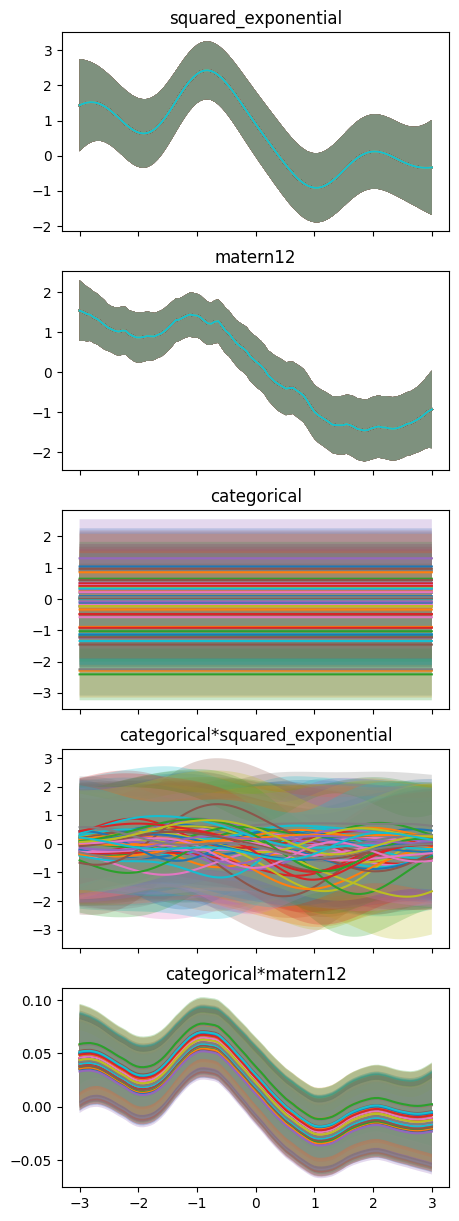

In [20]:
multi_x_grid_sorted = multi_x_grid[np.argsort(multi_x_grid[:, 1])]

mu_hat, var_hat = m_multi.predict_f(multi_x_grid_sorted)
y_hat, y_var_hat = m_multi.predict_y(multi_x_grid_sorted)

mse_y = ((multi_y - y_hat.numpy())**2).mean()
print(f"MSE of Y: {mse_y}")

W_ = m_multi.kernel.W.numpy()
num_latents = W_.shape[1]
kernel_list = [
    "squared_exponential",
    "matern12",
    "categorical",
    "categorical*squared_exponential",
    "categorical*matern12"
]

# Recover latent means using pseudo-inverse (no keep filtering)
latents_recovered = mu_hat.numpy() @ np.linalg.pinv(W_).T
l_mu_hat = latents_recovered
l_var_hat = np.transpose(np.linalg.pinv((W_)**2) @ np.transpose(var_hat))

# Plot each latent
figs, axs = plt.subplots(max(1, num_latents), 1, figsize=(5, 3*max(1, num_latents)), sharex=True)
if num_latents == 1:
    axs = [axs]
for i in range(num_latents):
    for idx in np.unique(multi_x_grid_sorted[:, 0]):
        mask = multi_x_grid_sorted[:, 0] == idx
        axs[i].fill_between(
            x=multi_x_grid_sorted[mask, 1].flatten(),
            y1=l_mu_hat[mask, i] - 1.96*np.sqrt(l_var_hat[mask, i]),
            y2=l_mu_hat[mask, i] + 1.96*np.sqrt(l_var_hat[mask, i]),
            alpha=0.25
        )
        axs[i].plot(multi_x_grid_sorted[mask, 1], l_mu_hat[mask, i])
    title = kernel_list[i] if i < len(kernel_list) else f"Latent {i+1}"
    axs[i].set_title(title)


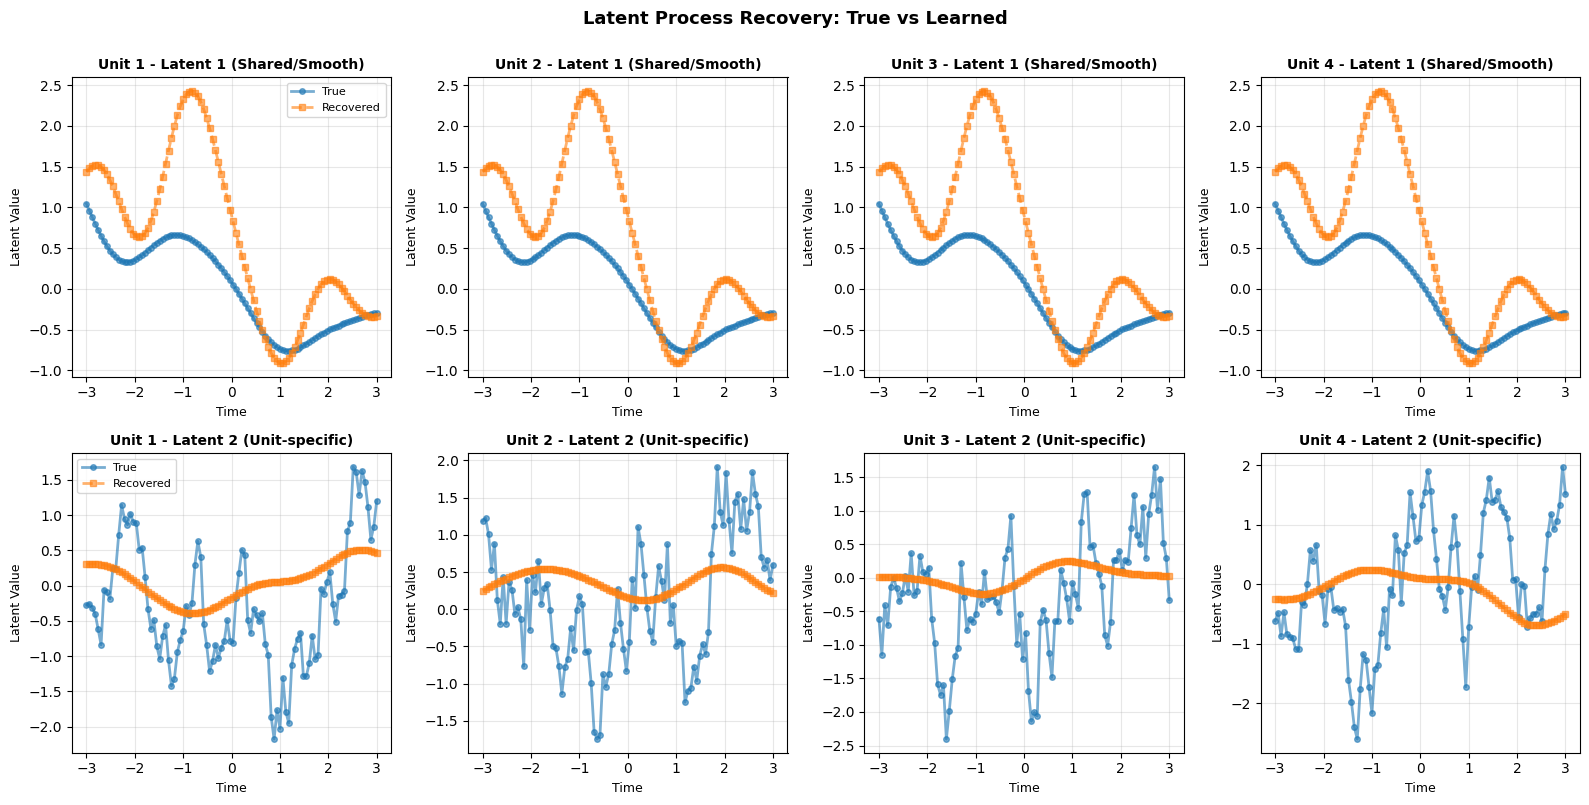


Latent process recovery quality:
  Latent 1 (Shared) - MSE: 0.664300
  Latent 2 (Unit-specific) - MSE: 2.137950


In [21]:
# Visualize learned vs true latent processes
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

# Get predictions on full grid
mu_hat_full, var_hat_full = m_multi.predict_f(multi_x_grid_sorted)
W_final = m_multi.kernel.W.numpy()

# Recover latent processes using pseudo-inverse
latents_recovered = mu_hat_full.numpy() @ np.linalg.pinv(W_final).T

# Also need to reorder the true latent processes to match multi_x_grid_sorted
sort_idx = np.argsort(multi_x_grid[:, 1])  # Get the sorting indices
lrv1_multi_sorted = lrv1_multi[sort_idx]
lrv2_multi_sorted = lrv2_multi[sort_idx]

# Plot first latent process (should correspond to smooth/shared component)
for unit_id in np.unique(multi_x_grid_sorted[:, 0])[:4]:
    unit_mask = multi_x_grid_sorted[:, 0] == unit_id
    unit_idx = int(unit_id) - 1
    
    # Plot each latent GP separately
    for i, latent_idx in enumerate([0, 3]):
        # True latent (first latent GP corresponds to shared smooth component)
        if i == 0:
            true_latent = lrv1_multi_sorted[unit_mask, 0]
            title = f"Unit {int(unit_id)} - Latent 1 (Shared/Smooth)"
        else:
            true_latent = lrv2_multi_sorted[unit_mask, 0]
            title = f"Unit {int(unit_id)} - Latent 2 (Unit-specific)"
        
        recovered_latent = latents_recovered[unit_mask, latent_idx]
        
        ax = axs[i, unit_idx]
        ax.plot(multi_x_grid_sorted[unit_mask, 1], true_latent, 'o-', alpha=0.6, 
                linewidth=2, label='True', markersize=4)
        ax.plot(multi_x_grid_sorted[unit_mask, 1], recovered_latent, 's--', alpha=0.6, 
                linewidth=2, label='Recovered', markersize=4)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Latent Value', fontsize=9)
        if unit_idx == 0:
            ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

plt.suptitle('Latent Process Recovery: True vs Learned', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\nLatent process recovery quality:")
print(f"  Latent 1 (Shared) - MSE: {np.mean((lrv1_multi_sorted - latents_recovered[:, 0:1])**2):.6f}")
print(f"  Latent 2 (Unit-specific) - MSE: {np.mean((lrv2_multi_sorted - latents_recovered[:, 1:2])**2):.6f}")

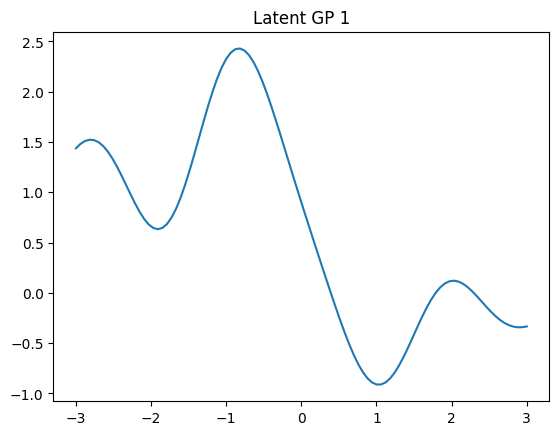

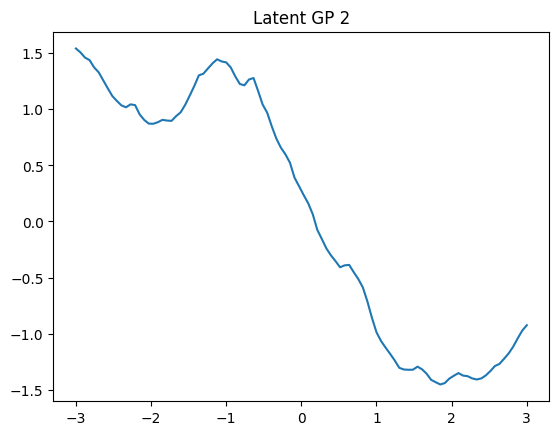

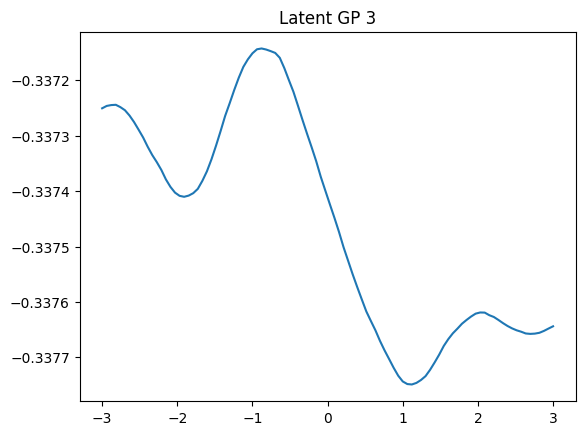

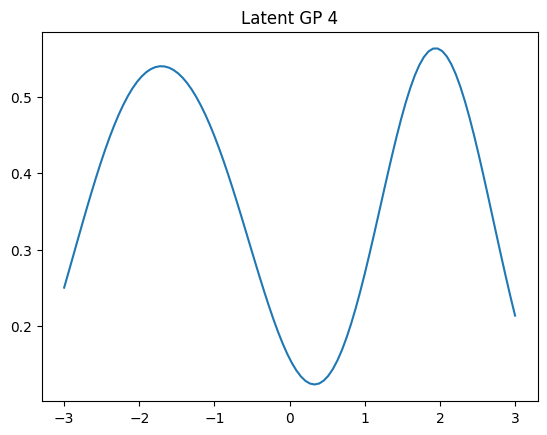

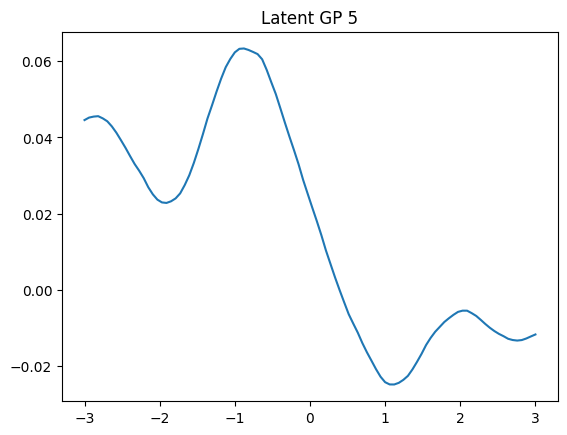

In [22]:
for i in range(latents_recovered.shape[1]):
    plt.plot(
        multi_x_grid_sorted[multi_x_grid_sorted[:, 0] == 2, 1],
        latents_recovered[multi_x_grid_sorted[:, 0] == 2, i]
    )
    plt.title(f"Latent GP {i+1}")
    plt.show()

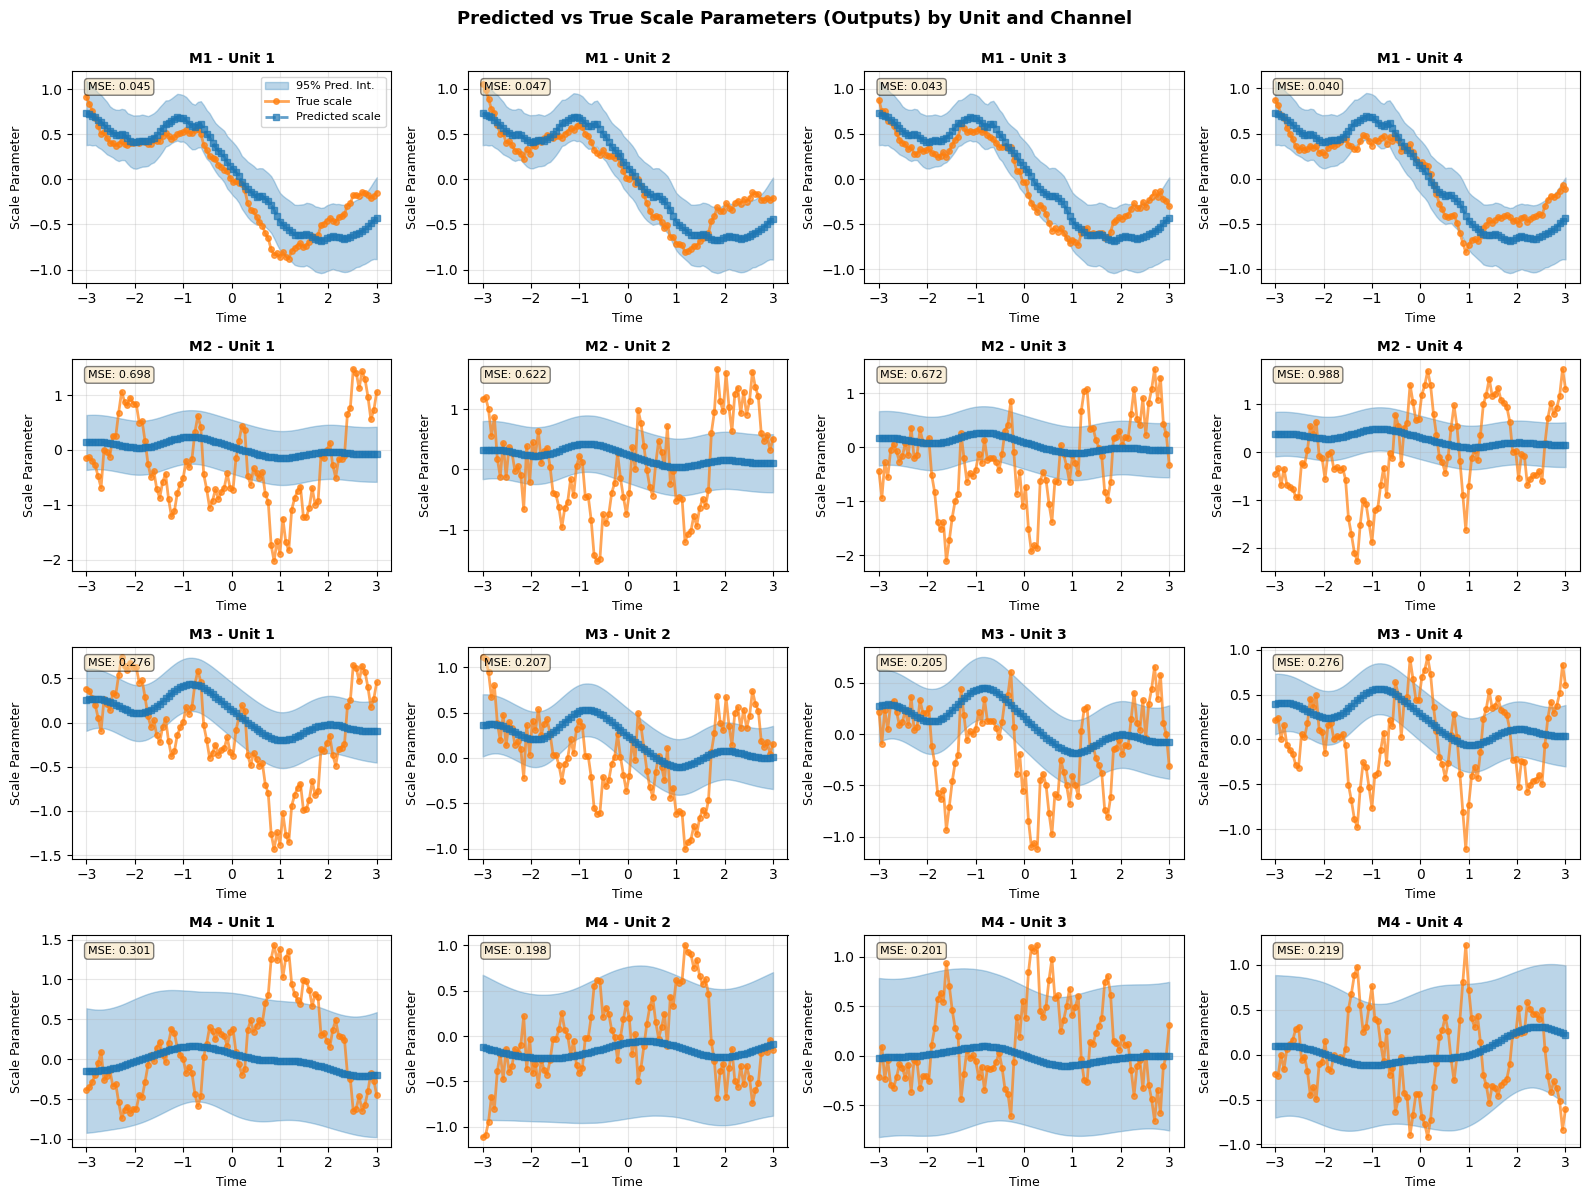


Predicted vs Observed Output Summary by Channel:
----------------------------------------------------------------------
M1: MSE=0.033496, MAE=0.149754
M2: MSE=0.686107, MAE=0.663361
M3: MSE=0.235086, MAE=0.389389
M4: MSE=0.246252, MAE=0.396112


In [23]:
# Visualize predicted vs observed outputs by unit
fig, axs = plt.subplots(4, 4, figsize=(16, 12))

# Get latent mean
f_pred_full, f_var_full = m_multi.predict_f(multi_x_grid_sorted)
f_pred_full = f_pred_full.numpy()
f_var_full = f_var_full.numpy()  # Convert variance to numpy

multi_mu_sorted = multi_mu[np.argsort(multi_x_grid[:, 1])]

# Plot for each output (M1-M4) and each unit
for output_idx in range(4):
    for unit_id in np.unique(multi_x_grid_sorted[:, 0])[:4]:
        unit_mask = multi_x_grid_sorted[:, 0] == unit_id
        unit_idx = int(unit_id) - 1
        
        ax = axs[output_idx, unit_idx]
        
        # True output (scale parameters)
        true_mu = multi_mu_sorted[multi_x_grid_sorted[:, 0] == unit_id, output_idx]
        predicted_mu = f_pred_full[unit_mask, output_idx]
        time_points = multi_x_grid_sorted[unit_mask, 1]
        
        # Plot with uncertainty bands
        std_pred = np.sqrt(f_var_full[unit_mask, output_idx])
        ax.fill_between(time_points, 
                         predicted_mu - 1.96*std_pred, 
                         predicted_mu + 1.96*std_pred,
                         alpha=0.3, color='tab:blue', label='95% Pred. Int.')
        ax.plot(time_points, true_mu, 'o-', alpha=0.7, linewidth=2, 
                label='True scale', markersize=4, color='tab:orange')
        ax.plot(time_points, predicted_mu, 's--', alpha=0.7, linewidth=2, 
                label='Predicted scale', markersize=4, color='tab:blue')
        
        # Compute and display error metric
        mse_unit = np.mean((true_mu - predicted_mu) ** 2)
        ax.text(0.05, 0.95, f'MSE: {mse_unit:.3f}', transform=ax.transAxes, 
                fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_title(f'M{output_idx+1} - Unit {int(unit_id)}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Scale Parameter', fontsize=9)
        if output_idx == 0 and unit_idx == 0:
            ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs True Scale Parameters (Outputs) by Unit and Channel', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary by output
print("\nPredicted vs Observed Output Summary by Channel:")
print("-" * 70)
for output_idx in range(4):
    mse_out = np.mean((multi_mu_sorted[:, output_idx] - f_pred_full[:, output_idx]) ** 2)
    mae_out = np.mean(np.abs(multi_mu_sorted[:, output_idx] - f_pred_full[:, output_idx]))
    print(f"M{output_idx+1}: MSE={mse_out:.6f}, MAE={mae_out:.6f}")

## Example: Using `multioutput_penalized_optimization` from waveome.model_search
This demonstrates fitting a multi-output penalized model using the method from the waveome package.

In [24]:
from waveome.model_search import GPSearch
import pandas as pd
import numpy as np

# Prepare data (using synthetic example from above)
X_df = pd.DataFrame(multi_x_grid_train, columns=['x1', 'x2'])
Y_df = pd.DataFrame(
    multi_y_train,
    columns=[f'output_{i}' for i in range(multi_y_train.shape[1])]
)

# Create GPSearch instance
ms = GPSearch(X_df, Y_df, unit_col='x1', outcome_likelihood='negativebinomial')

# Fit the multi-output penalized model
ms.multioutput_penalized_optimization(
    penalization_factor=10.0,
    num_opt_iter=5000,
    verbose=True,
    kernel_options={
        "unit_numeric_interactions": True,
        "kerns": [
            gpflow.kernels.SquaredExponential(),
            gpflow.kernels.Matern12()
        ]
    }
)

# Prune model output
ms.models['multioutput'].prune_latent_factors()

Built 20 latent kernels.


Iteration 0: Loss = 6652.50620037283, Total = 6662.295531984736
Iteration 500: Loss = 2791.193842360914, Total = 2792.565935505589
Iteration 1000: Loss = 2785.6912097819545, Total = 2786.4966648485542
Iteration 1500: Loss = 2777.5005658147215, Total = 2777.998267529284
Iteration 2000: Loss = 2772.3430934943735, Total = 2772.8857391836086
Iteration 2500: Loss = 2776.7352299949684, Total = 2777.425271130481


Iteration 2833: Early stopping - no improvement for 500 iterations
Pruning 18 latent factors. Keeping 2.
Re-optimizing model after pruning latent factors...
Iteration 0: Loss = 2894.3761517289295, Total = 2894.4135381379133
Iteration 500: Loss = 2889.792509096709, Total = 2889.830270652208
Iteration 576: Early stopping - no improvement for 500 iterations


(<Figure size 1200x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Multi-output Fit by x1'}, ylabel='output_0'>,
        <Axes: ylabel='output_1'>, <Axes: ylabel='output_2'>,
        <Axes: xlabel='x2', ylabel='output_3'>], dtype=object))

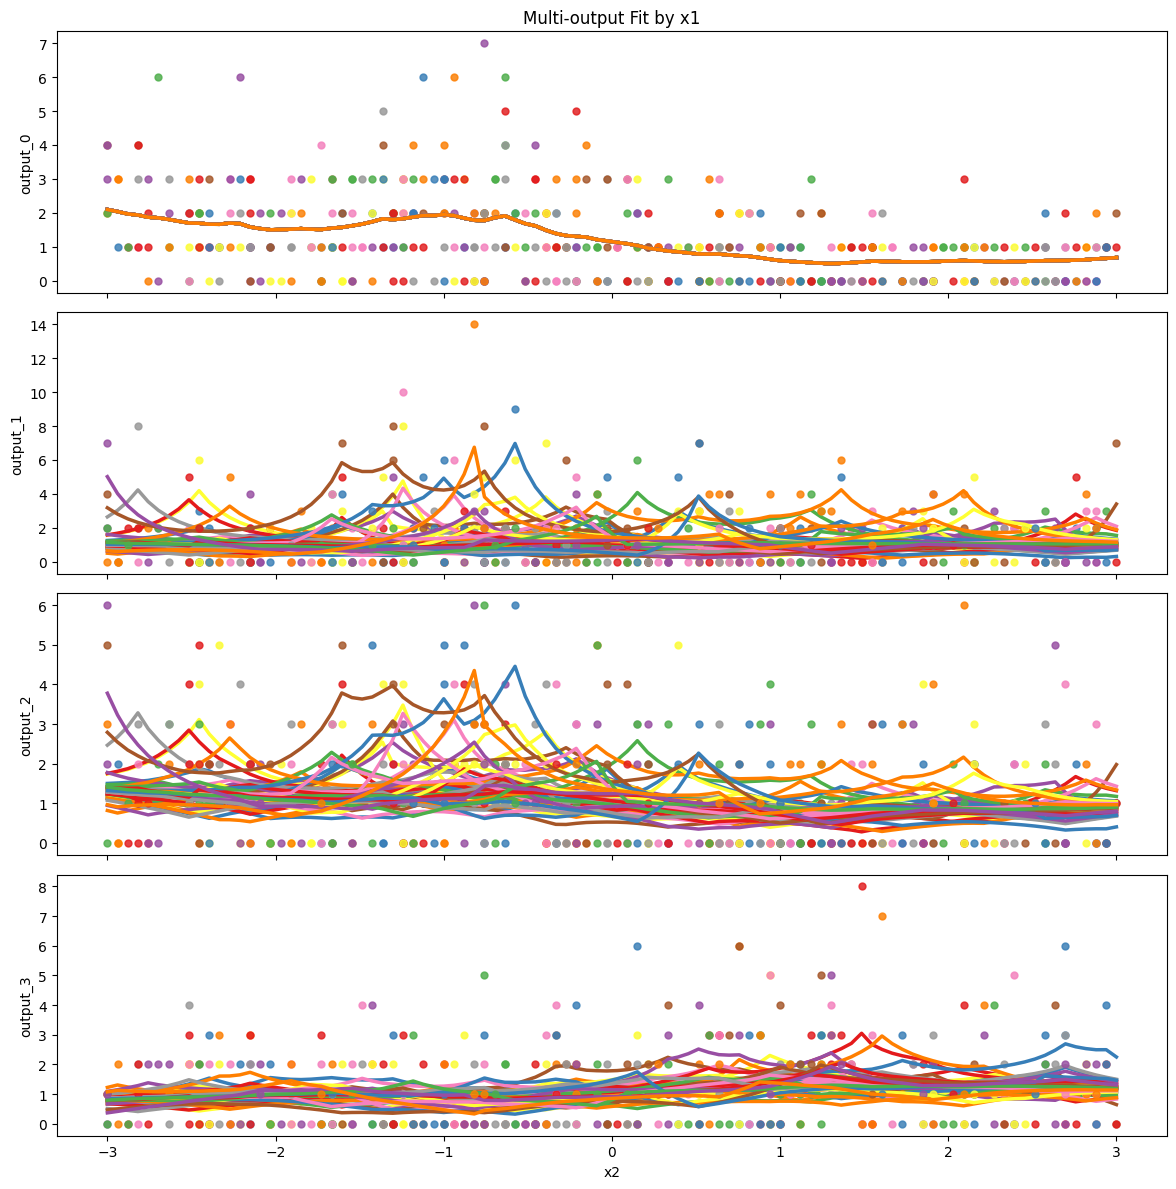

In [25]:
from plot_multioutput import plot_multioutput_predictions

# Assuming 'ms', 'X_df', 'Y_df' are defined
# and 'subject_id' is the name of your unit column in X_df

plot_multioutput_predictions(
    ms,
    X_df,
    Y_df,
    x_obs=X_df['x2'], # Pass the relevant x-axis column
    unit_col='x1'
)


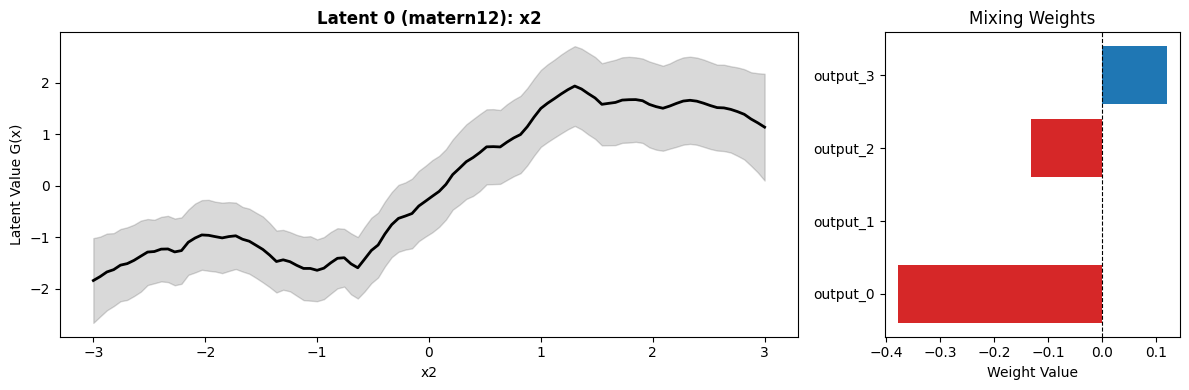

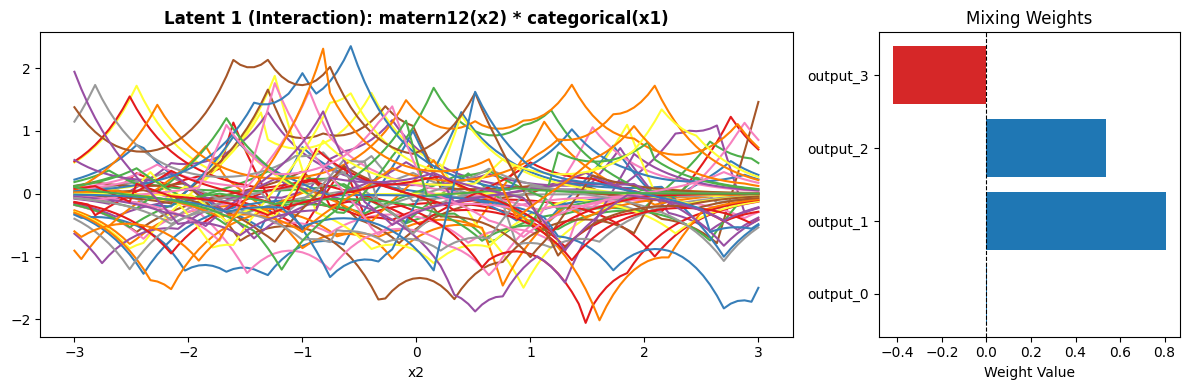

In [26]:
from plot_latent import plot_latent_processes

# Plot the underlying latent processes and mixing weights
# pX = np.linspace(x_obs.min(), x_obs.max(), 100)[:, None]
# plot_latent_processes(ms, X_df, pX)
plot_latent_processes(ms, X_df)


In [27]:
# Example: how to run the quick search — OFF by default because it can be slow
run_search = True  # set to True to run a small demo search locally
if run_search:
    # Use small settings for a quick demo; increase for real runs
    out = ms.multioutput_lam_search(
        k_fold=3,
        random_seed=9102,
        num_opt_iter=5000,
        verbose=True,
        lam_list=[0, 0.1, 1, 10, 100],
        kernel_options={
            "unit_numeric_interactions": True,
            "kerns": [
                gpflow.kernels.SquaredExponential(),
                gpflow.kernels.Matern12()
            ]
        }
    )
    print('Best penalization (from CV):', out.get('best_penalization'))
else:
    print('To run a demo CV search, set run_search = True in this cell.')


2026-01-07 14:07:53,256	INFO worker.py:1879 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Scheduling penalization_factor = 0
Scheduling penalization_factor = 0.1
Scheduling penalization_factor = 1
Scheduling penalization_factor = 10
Scheduling penalization_factor = 100


CV (lambda x fold):   0%|          | 0/15 [00:00<?, ?it/s]

(_multioutput_fold_worker pid=64091) WARNING:absl:At this time, the v2.11+ optimizer `tf.keras.optimizers.NaturalGradient` runs slowly on M1/M2 Macs, please use the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.NaturalGradient`.
(_multioutput_fold_worker pid=64095) WARNING:tensorflow:From /Users/allen/miniforge3/envs/waveome/lib/python3.11/site-packages/tensorflow/python/util/deprecation.py:660: calling map_fn_v2 (from tensorflow.python.ops.map_fn) with dtype is deprecated and will be removed in a future version.
(_multioutput_fold_worker pid=64095) Instructions for updating:
(_multioutput_fold_worker pid=64095) Use fn_output_signature instead
(_multioutput_fold_worker pid=64095) WARNING:tensorflow:From /Users/allen/miniforge3/envs/waveome/lib/python3.11/site-packages/tensorflow/python/util/deprecation.py:660: calling map_fn_v2 (from tensorflow.python.ops.map_fn) with dtype is deprecated and will be removed in a future version.
(_multioutput_fold_worker pid=640

Fitting final multioutput model with penalization=0.1


Built 20 latent kernels.


Iteration 0: Loss = 7269.025489142572, Total = 7277.368179624688
Iteration 500: Loss = 3035.8108146746613, Total = 3035.877660338076
Iteration 1000: Loss = 3035.8961600215252, Total = 3036.055656611535


KeyboardInterrupt: 

In [ ]:
import gpflow, tensorflow_probability as tfp
m = ms.models['multioutput']
print(type(m.kernel))
print("W type:", type(m.kernel.W))
print("is Parameter:", isinstance(m.kernel.W, gpflow.Parameter))
print("W.prior:", getattr(m.kernel.W, "prior", None))

<class 'gpflow.kernels.multioutput.kernels.LinearCoregionalization'>
W type: <class 'gpflow.base.Parameter'>
is Parameter: True
W.prior: tfp.distributions.Horseshoe("Horseshoe", batch_shape=[], event_shape=[], dtype=float64)


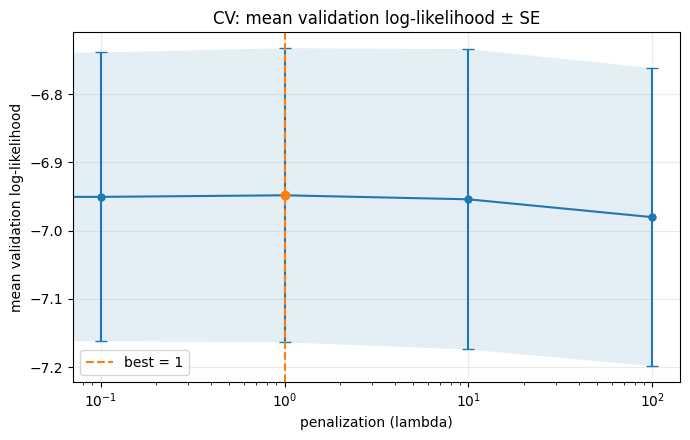

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multioutput_cv(cv_out, log_x=True, xlabel='penalization (lambda)', ylabel='mean validation log-likelihood', title='CV: mean validation log-likelihood ± SE'):
    """
    Plot cross-validation results produced by `GPSearch.multioutput_lam_search`.

    Expects `cv_out` to contain:
      - 'cv_log_lik' : either a 2D array (num_lams x num_folds) or a dict {lam: [fold_vals,...]}
      - 'lam_list' (optional) : list/array of lambdas corresponding to rows of the array
      - 'best_penalization' (optional) : chosen best lambda (will be marked)

    Returns (fig, ax).
    """
    # extract cv_log_lik
    if 'cv_log_lik' not in cv_out:
        raise KeyError("cv_out must contain 'cv_log_lik'")

    cv = cv_out['cv_log_lik']

    # determine lam_list
    lam_list = None
    for key in ('lam_list', 'penalization_list', 'lam_grid', 'lambdas'):
        if key in cv_out:
            lam_list = np.asarray(cv_out[key], dtype=float)
            break

    if isinstance(cv, dict):
        # dict: keys = lambda values (possibly strings); values = list of fold scores
        keys = sorted([float(k) for k in cv.keys()])
        lam_list = np.asarray(keys, dtype=float) if lam_list is None else lam_list
        vals = [np.asarray(cv[k], dtype=float) for k in keys]
    else:
        arr = np.asarray(cv, dtype=float)
        if arr.ndim == 2:
            # rows -> lambdas
            if lam_list is None:
                lam_list = np.arange(arr.shape[0], dtype=float)
            vals = [arr[i, :] for i in range(arr.shape[0])]
        elif arr.ndim == 1:
            # single fold per lambda
            if lam_list is None:
                lam_list = np.arange(arr.shape[0], dtype=float)
            vals = [[v] for v in arr]
        else:
            raise ValueError("Unsupported shape for 'cv_log_lik'")

    # ensure lam_list length matches
    if len(lam_list) != len(vals):
        lam_list = np.asarray([float(x) for x in lam_list[:len(vals)]])

    means = np.array([np.mean(v) for v in vals])
    sems = np.array([(np.std(v, ddof=1) / np.sqrt(len(v))) if len(v) > 1 else 0.0 for v in vals])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.errorbar(lam_list, means, yerr=sems, fmt='o-', capsize=4, markersize=5, lw=1.5)
    ax.fill_between(lam_list, means - sems, means + sems, alpha=0.12)

    best = cv_out.get('best_penalization') or cv_out.get('best_lambda') or cv_out.get('best_lam')
    if best is not None:
        best = float(best)
        ax.axvline(best, color='C1', linestyle='--', lw=1.5, label=f'best = {best:.5g}')
        # annotate approximate y value at best
        y_at_best = np.interp(best, lam_list, means)
        ax.scatter([best], [y_at_best], color='C1', zorder=10)
        ax.legend(loc='best', frameon=True)

    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    return fig, ax

# Example usage:
fig, ax = plot_multioutput_cv(out, log_x=True)

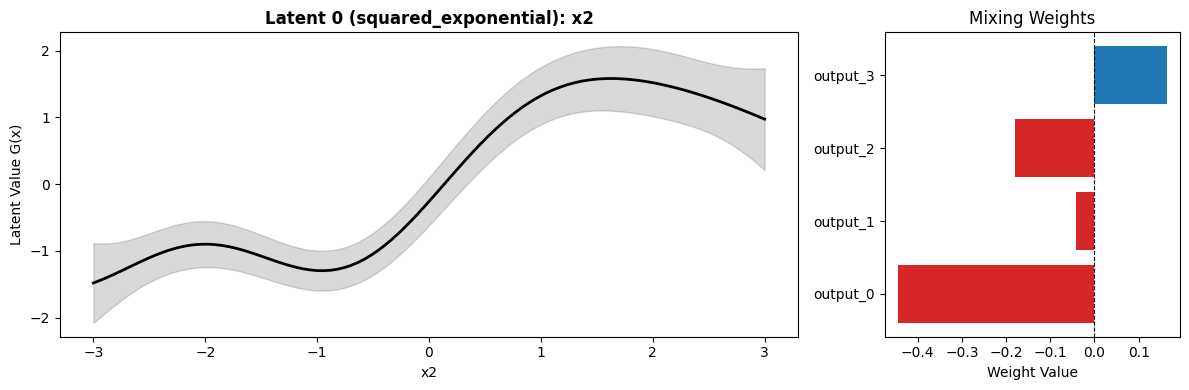

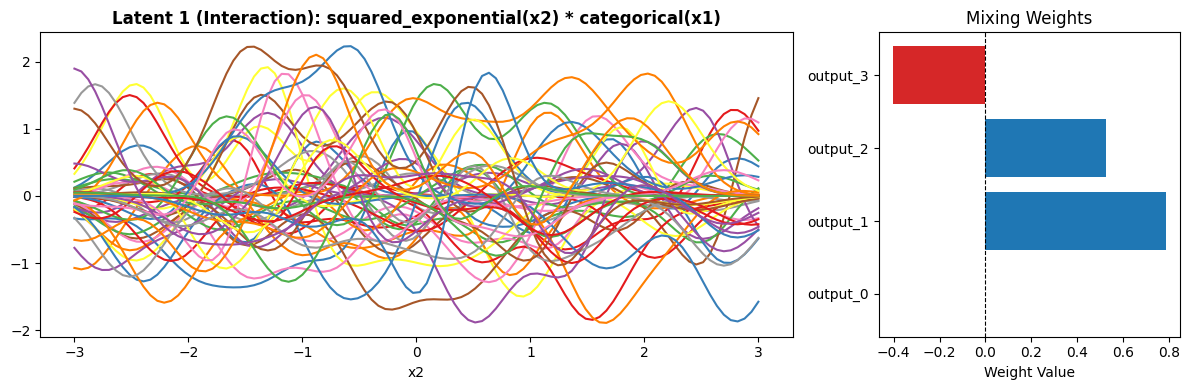

In [ ]:
plot_latent_processes(ms, X_df)